# Prepare Data
## Import preprocessed data
Important things to note:
- New target is CLUSTER (5 possible designations)
- Train/test split is implemented
- Categorical features are specified to be encoded in a fitting manner (in this case, one-hot encoded)
- Numeric features will be left alone

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('data//2_clustered//clustered_dataset.csv')

y = data.cluster
X = data.drop(columns=['cluster', 'track_id', 'artists', 'track_name', 'album_name', 'popularity', 'track_genre', 'duration_min'])
print(X.columns)



# Categorical features (one-hot encode these)
categorical_cols = ['mode', 'time_signature', 'key']
print("Cardinality of categorical columns:")
for col in categorical_cols:
    print(f"{col}: {X[col].nunique()}")
# Only key (12) may have too high of a cardinality, especially since it's already likely not a very important feature, so we'll drop it.
categorical_cols.remove('key')
X.drop(columns=['key'], inplace=True)

# Stratified split to maintain class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

numerical_cols = ['duration_ms','explicit','danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']
print("Numerical columns:", numerical_cols)

Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='str')
Cardinality of categorical columns:
mode: 2
time_signature: 5
key: 12
Numerical columns: ['duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


## Begin model preprocessing
- One hot encoding occurs for categorical columns
- Numerical columns are left alone (no scaling/normalization necessary for Decision Tree-based model structure)

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
 )

# Random Forest model
## Training

In [3]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=0)
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

my_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## Evaluation
### Classification Report
For both testing AND training accuracy

In [4]:
from sklearn.metrics import classification_report

train_preds = my_pipeline.predict(X_train)
print("Training Accuracy:", (train_preds == y_train).mean())
train_report = classification_report(y_train, train_preds, output_dict=True)
df_train_report = pd.DataFrame(train_report).T

test_preds = my_pipeline.predict(X_test)
print("Testing Accuracy:", (test_preds == y_test).mean())
test_report = classification_report(y_test, test_preds, output_dict=True)
df_test_report = pd.DataFrame(test_report).T

Training Accuracy: 0.9271788548971257
Testing Accuracy: 0.5945838837516513


92.7% training accuracy
59.5% testing accuracy

# Visualizations

## Accuracy Bar Chart

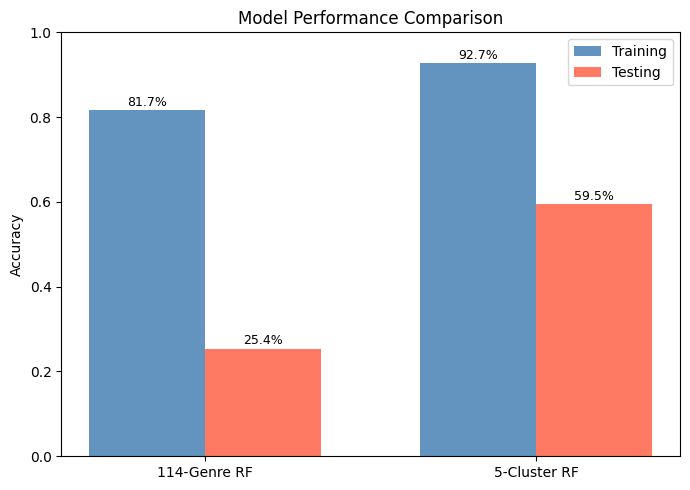

In [5]:
import matplotlib.pyplot as plt
import numpy as np

models = ['114-Genre RF', '5-Cluster RF']
train_accs = [0.8173, 0.9272]
test_accs = [0.2539, 0.5946]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width / 2, train_accs, width, label='Training', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width / 2, test_accs, width, label='Testing', color='tomato', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Comparison')
ax.legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Per genre Precision, Recall, & F1 Score

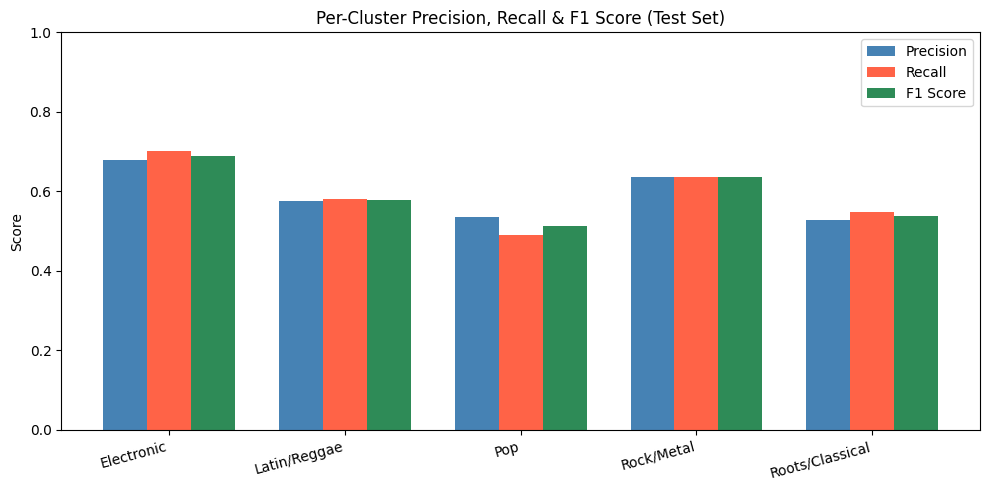

In [6]:
import matplotlib.pyplot as plt
import numpy as np

clusters = list(my_pipeline.named_steps['model'].classes_)
short_names = ['Electronic', 'Latin/Reggae', 'Pop', 'Rock/Metal', 'Roots/Classical']

precision = [test_report[c]['precision'] for c in clusters]
recall = [test_report[c]['recall'] for c in clusters]
f1 = [test_report[c]['f1-score'] for c in clusters]

x = np.arange(len(clusters))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x, recall, width, label='Recall', color='tomato')
ax.bar(x + width, f1, width, label='F1 Score', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Per-Cluster Precision, Recall & F1 Score (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

## Confusion Matrix

In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_preds)
cm_df = pd.DataFrame(cm, index=my_pipeline.named_steps['model'].classes_, columns=my_pipeline.named_steps['model'].classes_)
cm_df

,Electronic & Dance Music,"Latin, Reggae & World Cultural Traditions","Pop, Entertainment & Global Pop","Rock, Metal & Punk Universe","Roots, Classical & Introspective Music"
Electronic & Dance Music,3637,320,386,326,515
"Latin, Reggae & World Cultural Traditions",438,2646,553,355,573
"Pop, Entertainment & Global Pop",532,627,2150,487,594
"Rock, Metal & Punk Universe",346,320,397,2668,464
"Roots, Classical & Introspective Music",408,681,528,357,2402


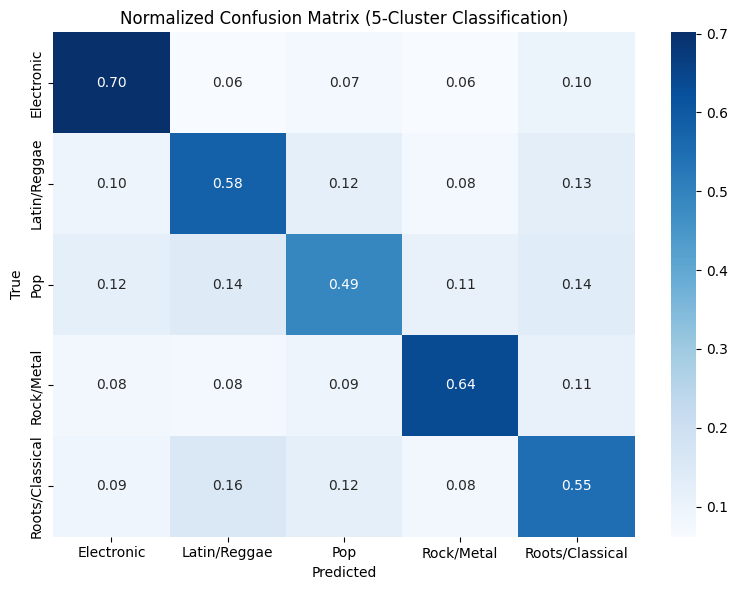

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

short_names = ['Electronic', 'Latin/Reggae', 'Pop', 'Rock/Metal', 'Roots/Classical']
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm.values, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Normalized Confusion Matrix (5-Cluster Classification)')
plt.tight_layout()
plt.show()

## Feature Importance (easily extracted from the Random Forest model)

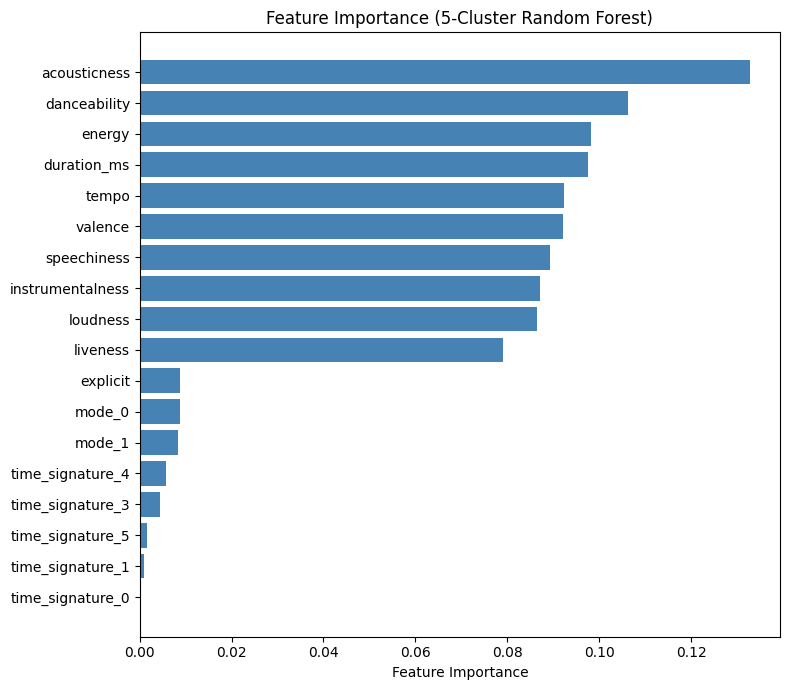

In [9]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = my_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = my_pipeline.named_steps['model'].feature_importances_

clean_names = [n.split('__')[-1] for n in feature_names]
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh([clean_names[i] for i in indices], importances[indices], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance (5-Cluster Random Forest)')
plt.tight_layout()
plt.show()

All the categorical columns wound up being pretty low importance, just as they were with the initial classification model. This could justify removing them, but they are left in simply to make a more fair comparison with the initial model.

## Violin plots for Clusters
Features deemed important above were selected to observe any distinct patterns

/tmp/ipykernel_19759/2020128200.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='cluster', y=feature, ax=ax, palette='tab10')
/tmp/ipykernel_19759/2020128200.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='cluster', y=feature, ax=ax, palette='tab10')
/tmp/ipykernel_19759/2020128200.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='cluster', y=feature, ax=ax, palette='tab10')


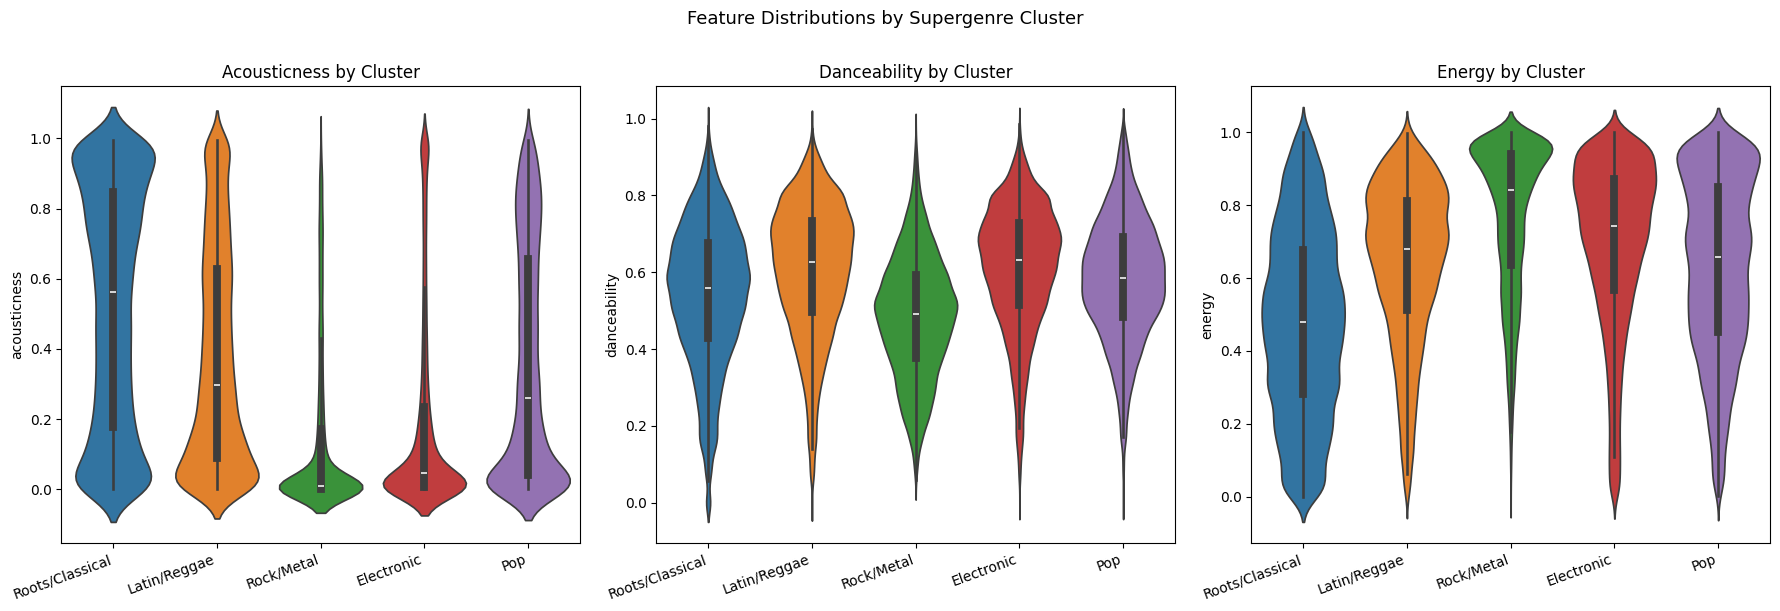

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

violin_features = ['acousticness', 'danceability', 'energy']
short_names = {
    'Electronic & Dance Music': 'Electronic',
    'Latin, Reggae & World Cultural Traditions': 'Latin/Reggae',
    'Pop, Entertainment & Global Pop': 'Pop',
    'Rock, Metal & Punk Universe': 'Rock/Metal',
    'Roots, Classical & Introspective Music': 'Roots/Classical'
}

plot_data = data[['cluster'] + violin_features].copy()
plot_data['cluster'] = plot_data['cluster'].map(short_names)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, feature in zip(axes, violin_features):
    sns.violinplot(data=plot_data, x='cluster', y=feature, ax=ax, palette='tab10')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
    ax.set_title(f'{feature.capitalize()} by Cluster')
    ax.set_xlabel('')
plt.suptitle('Feature Distributions by Supergenre Cluster', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()